<a href="https://colab.research.google.com/github/pablo-arantes/spde-workshop-ai-protein-design/blob/main/Notebook1_RFdiffusion3_Binder_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Workshop: *De Novo* Protein Binder Design with RFdiffusion3
---
**Pipeline:** RFdiffusion3 → LigandMPNN → ColabFold (AF2 Multimer v3) → Screening

This notebook implements an end-to-end computational protein design pipeline:

1. **RFdiffusion3 (RFD3)** — Generates novel protein backbone structures conditioned on a target
2. **LigandMPNN** — Optimizes amino acid sequences for the generated backbones
3. **ColabFold (AlphaFold2 Multimer v3)** — Re-predicts the complex to validate designs
4. **Screening** — Filters designs by structural quality metrics (ipTM, pTM, pLDDT)

> **⚡ Runtime**: Go to *Runtime → Change runtime type → GPU (T4 or A100)*
>
> **⏱ Estimated time**: ~30–90 min depending on GPU and number of designs

> **💡 How to use**: Each section has a **form** with parameters you can adjust.
> Click the ▶ button to run each cell. Code is hidden — click "Show code" to inspect.

## 📑 Table of Contents

| Section | Description |
|---------|------------|
| **0. Setup** | GPU check, install dependencies |
| **1. Configuration** | Define your target protein and design parameters |
| **2. RFdiffusion3** | Generate novel backbone structures |
| **3. LigandMPNN** | Optimize sequences for each backbone |
| **4. ColabFold** | Re-predict structures with AlphaFold2 |
| **5. Screening** | Filter by ipTM, pTM, pLDDT metrics |
| **6. 3D Visualization** | Interactive molecular visualization with py3Dmol |
| **7. Download** | Package and download all results |

---
## 0. Environment Setup

This section checks for GPU availability and installs all required packages.
The pipeline **requires a GPU** — please ensure you have selected a GPU runtime.

**Packages installed:**
- `biopython` — PDB file parsing
- `py3Dmol` — Interactive 3D molecular visualization
- `pandas`, `numpy`, `matplotlib` — Data analysis and plotting

In [1]:
#@title **0.1 — Check GPU & Install Core Packages** { display-mode: "form" }
#@markdown > Run this cell first. It verifies GPU availability and installs dependencies.

import os, subprocess, sys, time, shutil, glob, json, math
from pathlib import Path

# --- GPU Check ---
gpu_check = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if gpu_check.returncode != 0:
    raise RuntimeError(
        "❌ No GPU detected! Go to Runtime → Change runtime type → GPU (T4/A100)"
    )
print("✅ GPU detected:")
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

# --- Install core packages ---
!pip install -q biopython pandas numpy matplotlib py3Dmol ipywidgets

print("\n✅ Core packages installed successfully")

✅ GPU detected:
NVIDIA L4, 23034 MiB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 134.8 MB/s eta 0:00:00

✅ Core packages installed successfully


### 0.2  Install Foundry (RFdiffusion3 + LigandMPNN)

**Foundry** is the unified framework from the Baker Lab that bundles RFdiffusion3
and MPNN models. It provides the `rfd3` and `mpnn` command-line tools.

This cell clones the repository and performs an editable install (~2-5 min).

In [2]:
#@title **0.2 — Install Foundry (RFdiffusion3 + MPNN)** { display-mode: "form" }
#@markdown > Installs the official RosettaCommons **Foundry** package (`rc-foundry` on PyPI),
#@markdown > which provides the `rfd3` and `mpnn` command-line tools. Takes ~2-4 minutes.
#@markdown >
#@markdown > (Earlier versions of this notebook cloned an unofficial fork and did an editable
#@markdown > install, which broke often. The published `rc-foundry` package is far more reliable.)

t0 = time.time()
!pip install -q --no-warn-conflicts "rc-foundry[all]"

print(f"✅ Foundry installed in {time.time()-t0:.0f}s")
!rfd3 --help | head -3
!mpnn --help | head -3

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.4/293.4 kB 27.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.0/517.0 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.9/467.9 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

### 0.3  Install ColabFold (AlphaFold2)

**ColabFold** provides a fast implementation of AlphaFold2 optimized for Colab.
We install it with CUDA 12 support for GPU-accelerated structure prediction.

In [3]:
#@title **0.3 — Install ColabFold + JAX (CUDA)** { display-mode: "form" }
#@markdown > Installs ColabFold and a CUDA-enabled JAX build. Takes ~2-3 minutes.
#@markdown >
#@markdown > We install the `alphafold-minus-jax` extra (not `alphafold`) and let pip resolve
#@markdown > the JAX/CUDA build that matches *this* Colab runtime, instead of pinning an exact
#@markdown > JAX version — a pinned version drifts out of sync with Colab's CUDA driver over
#@markdown > time and is a common source of "notebook worked last month, fails today" bugs.

# !pip install -q --no-warn-conflicts "colabfold[alphafold-minus-jax]"
# !pip install -q --upgrade "jax[cuda12]"

!pip install -q --no-warn-conflicts "colabfold[alphafold-minus-jax]"
# openmm + pdbfixer are required by ColabFold's Amber relax (use_relax=True)
!pip install -q --no-warn-conflicts openmm pdbfixer
!pip install -q --upgrade "jax[cuda12]"


import jax
print(f"✅ JAX version: {jax.__version__}")
print(f"   JAX devices: {jax.devices()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.1/264.1 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.8/81.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.9/665.9 kB 43.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 106.4 MB/s eta 0:00:00
✅ JAX version: 0.11.1
   JAX devices: [CudaDevice(id=0)]


In [4]:
#@title **0.3b — Fix JAX/ColabFold Compatibility** { display-mode: "form" }
#@markdown > Downgrades JAX to a version compatible with ColabFold (dm-haiku)
#@markdown > before it tries to import the old `jax.core.DropVar` API.

!pip install -q --upgrade "jax[cuda12]<0.11" "jaxlib[cuda12]<0.11"

import jax
print(f"✅ JAX pinned to: {jax.__version__} (compatible with ColabFold)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 MB 4.5 MB/s eta 0:00:00
✅ JAX pinned to: 0.11.1 (compatible with ColabFold)


---
## 1. Configuration — Define Your Design Parameters

⬇️ **Use the form below to configure your design.** Each parameter has a description.

| Parameter | Description | Suggested Range |
|-----------|-------------|-----------------|
| `TARGET_NAME` | A short name for your target protein | Any string |
| `TARGET_PDB` | Filename of the target PDB | Upload to Colab |
| `TARGET_CHAIN` | Chain ID in the PDB to target | A, B, C... |
| `BINDER_MIN / MAX` | Min/max length of the binder | 50–150 residues |
| `HOTSPOTS` | Target residues the binder should contact | Comma-separated |
| `NUM_BACKBONES` | Backbone structures to generate | 4–100 |
| `MPNN_SEQS` | Sequences per backbone | 4–16 |

> **💡 Tip**: Start with 4 backbones × 4 seqs = 16 designs to test the pipeline.

In [5]:
#@title **1.0 — Design Configuration** { display-mode: "form" }

#@markdown ### 🎯 Target Protein
TARGET_NAME  = "FPR2"           #@param {type:"string"}
TARGET_PDB   = "FPR2.pdb" #@param {type:"string"}
TARGET_CHAIN = "B"               #@param ["A", "B", "C", "D", "E", "F"]

#@markdown ### 🧬 Binder Design
BINDER_MIN   = 5   #@param {type:"slider", min:5, max:200, step:5}
BINDER_MAX   = 20  #@param {type:"slider", min:15, max:250, step:5}

#@markdown ### 📍 Hotspot Residues
#@markdown Comma-separated residue numbers on the target chain that the binder should contact.
HOTSPOTS_STR = "84,88,172,180,263,266,176,173,262" #@param {type:"string"}

#@markdown ### 🔢 Sampling Parameters
#@markdown Total backbones generated = `N_BATCHES × BATCH_SIZE` (derived automatically below).
NUM_BACKBONES = 4   #@param {type:"slider", min:1, max:100, step:1}

#@markdown ### 🧪 Sequence Optimization
MPNN_SEQS   = 4             #@param {type:"slider", min:1, max:32, step:1}
MPNN_MODEL  = "solmpnn"  #@param ["ligandmpnn", "solmpnn"]

# ===== Process parameters =====
if BINDER_MAX < BINDER_MIN:
    raise ValueError(f"BINDER_MAX ({BINDER_MAX}) must be >= BINDER_MIN ({BINDER_MIN})")

_hotspot_residues = [int(x.strip()) for x in HOTSPOTS_STR.split(",") if x.strip()]
# RFD3's input spec expects a *dict* mapping "<chain><resnum>" -> comma-separated atom names,
# not a plain list of residues. "CA" is a safe default; for finer control over which atoms on
# a hotspot residue must be contacted, edit this dict directly (see Foundry's rfd3 input docs).
SELECT_HOTSPOTS = {f"{TARGET_CHAIN}{r}": "CA" for r in _hotspot_residues}

# BATCH_SIZE x N_BATCHES = NUM_BACKBONES (rfd3's actual CLI knobs are n_batches/diffusion_batch_size)
BATCH_SIZE = min(NUM_BACKBONES, 4)
N_BATCHES  = math.ceil(NUM_BACKBONES / BATCH_SIZE)

WORK_DIR    = f"/content/rfd3_{TARGET_NAME}"
RESULTS_DIR = f"/content/results_{TARGET_NAME}"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

CONTIG = f"{BINDER_MIN}-{BINDER_MAX},/0,{TARGET_CHAIN}1-200"

print("=" * 60)
print(f"  Target:     {TARGET_NAME} ({TARGET_PDB}, chain {TARGET_CHAIN})")
print(f"  Binder:     {BINDER_MIN}–{BINDER_MAX} residues")
print(f"  Hotspots:   {SELECT_HOTSPOTS} ({len(SELECT_HOTSPOTS)} residues)")
print(f"  Backbones:  {N_BATCHES * BATCH_SIZE} ({N_BATCHES} batches x {BATCH_SIZE})")
print(f"  Sequences:  {MPNN_SEQS} per backbone = ~{N_BATCHES * BATCH_SIZE * MPNN_SEQS} total designs")
print(f"  MPNN model: {MPNN_MODEL}")
print(f"  Contig:     {CONTIG}")
print("=" * 60)

  Target:     FPR2 (FPR2.pdb, chain B)
  Binder:     5–20 residues
  Hotspots:   {'B84': 'CA', 'B88': 'CA', 'B172': 'CA', 'B180': 'CA', 'B263': 'CA', 'B266': 'CA', 'B176': 'CA', 'B173': 'CA', 'B262': 'CA'} (9 residues)
  Backbones:  4 (1 batches x 4)
  Sequences:  4 per backbone = ~16 total designs
  MPNN model: solmpnn
  Contig:     5-20,/0,B1-200


### 1.1  Upload Your Target PDB

Choose how to provide your target PDB file:
- **Option A**: Upload interactively from your computer
- **Option B**: Download directly from RCSB PDB by ID

In [6]:
#@title **1.1 — Load Target PDB** { display-mode: "form" }

#@markdown ### Choose how to load the PDB:
pdb_source = "Upload from computer"  #@param ["Upload from computer", "Download from RCSB"]
RCSB_PDB_ID = "1AKI"                #@param {type:"string"}

pdb_path = f"/content/{TARGET_PDB}"

if pdb_source == "Upload from computer":
    from google.colab import files
    print("📂 Please select your PDB file...")
    uploaded = files.upload()
    if uploaded:
        # Move uploaded file to expected path
        for fname, content in uploaded.items():
            with open(pdb_path, "wb") as f:
                f.write(content)
            print(f"   Saved as: {pdb_path}")
else:
    print(f"📥 Downloading PDB {RCSB_PDB_ID} from RCSB...")
    !wget -q "https://files.rcsb.org/download/{RCSB_PDB_ID}.pdb" -O {pdb_path}

# Verify and extract sequence
if os.path.isfile(pdb_path):
    size_kb = os.path.getsize(pdb_path) / 1024
    print(f"\n✅ PDB loaded: {pdb_path} ({size_kb:.1f} KB)")

    from Bio.PDB import PDBParser
    # protein_letters_3to1 lives in Bio.Data.PDBData on current Biopython (it used to be
    # importable from Bio.PDB.Polypeptide, which raises ImportError on modern Biopython).
    # Fall back to the older location for very old Biopython installs.
    try:
        from Bio.Data.PDBData import protein_letters_3to1
    except ImportError:
        from Bio.Data.SCOPData import protein_letters_3to1
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("target", pdb_path)
    target_residues = []
    for chain in structure[0]:
        if chain.id == TARGET_CHAIN:
            for res in chain:
                if res.id[0] == " ":
                    rn = res.get_resname()
                    target_residues.append(protein_letters_3to1.get(rn, "X"))
    TARGET_SEQUENCE = "".join(target_residues)
    if not TARGET_SEQUENCE:
        raise ValueError(
            f"No residues found for chain '{TARGET_CHAIN}' in {pdb_path}. "
            f"Check that TARGET_CHAIN in cell 1.0 matches a chain ID in your PDB file."
        )
    CONTIG = f"{BINDER_MIN}-{BINDER_MAX},/0,{TARGET_CHAIN}1-{len(TARGET_SEQUENCE)}"
    print(f"   Chain {TARGET_CHAIN}: {len(TARGET_SEQUENCE)} residues")
    print(f"   Sequence: {TARGET_SEQUENCE[:60]}...")
    print(f"   CONTIG updated: {CONTIG}")
else:
    print(f"⚠️  PDB not found at {pdb_path}")
    print("   Please re-run this cell and upload your file.")

📂 Please select your PDB file...


Saving FPR2.pdb to FPR2.pdb
   Saved as: /content/FPR2.pdb

✅ PDB loaded: /content/FPR2.pdb (382.2 KB)
   Chain B: 299 residues
   Sequence: SAGYTVLRILPLVVLGVTFVLGVLGNGLVIWVAGFRMTRTVTTICYLNLALADFSFTATL...
   CONTIG updated: 5-20,/0,B1-299


### 1.2  Download Model Checkpoints

RFdiffusion3 and LigandMPNN require pre-trained model weights (~600 MB total).
Update the download URLs below if needed.

In [7]:
#@title **1.2 — Download Model Checkpoints** { display-mode: "form" }
#@markdown > Checkpoints (~600 MB total) are fetched with Foundry's own installer, `foundry
#@markdown > install`, which knows the real download locations.

CKPT_DIR = "/content/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

print("📥 Downloading RFD3 + MPNN checkpoints via `foundry install` (~600 MB, a few minutes)...")
t0 = time.time()
!foundry install rfd3 ligandmpnn solublempnn --checkpoint-dir {CKPT_DIR}
print(f"   Done in {time.time()-t0:.0f}s")
!foundry list-installed

# Locate the actual checkpoint files on disk (robust to Foundry's internal folder layout).
def _find_ckpt(pattern):
    hits = sorted(glob.glob(os.path.join(CKPT_DIR, "**", pattern), recursive=True))
    return hits[0] if hits else None

RFD3_CKPT = _find_ckpt("*rfd3*.ckpt")
if MPNN_MODEL == "ligandmpnn":
    mpnn_pattern = "*ligand*mpnn*.pt"
else:
    mpnn_pattern = "*solublempnn*.pt"
MPNN_CKPT = _find_ckpt(mpnn_pattern) or _find_ckpt("*mpnn*.pt")

for name, path in [("RFD3", RFD3_CKPT), ("MPNN", MPNN_CKPT)]:
    if path and os.path.isfile(path):
        print(f"✅ {name}: {os.path.getsize(path)/1e6:.0f} MB — {path}")
    else:
        print(f"⚠️  {name}: checkpoint not found under {CKPT_DIR}")
        print(f"   rfd3/mpnn will still try their default checkpoint search path "
              f"(~/.foundry/checkpoints) at run time.")

📥 Downloading RFD3 + MPNN checkpoints via `foundry install` (~600 MB, a few minutes)...
/usr/local/lib/python3.13/dist-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
Install target: /content/checkpoints

Installing rfd3: RFdiffusion3 checkpoint
✓ Successfully installed rfd3 to /content/checkpoints/rfd3_latest.ckpt

Installing ligandmpnn: LigandMPNN checkpoint
⠋ Downloading ligandmpnn_v_32_010_25.pt ━━━━━━━━━━ 0.0/10.5   182.6 MB/s 0:00:01
⠹ Downloading ligandmpnn_v_32_010_25.pt ━━━━━━━━━━ 0.1/10.5   497.9 kB/s 0:00:21
⠸ Downloading ligandmpnn_v_32_010_25.pt ━━━━━━━━━━ 0.1/10.5   497.9 kB/s 0:00:21
⠼ Downloading ligandmpnn_v_32_010_25.pt ━━━━━━━━━━ 0.2/10.5   597.4 kB/s 0:00:18
⠴ Downloading ligandmpnn_v_32_010_25.pt ━━━━━━━━━━ 0.2/10.5   597.4 kB/s 0:00:18
⠧ Downloading ligandmpnn_v_32_010_25.pt ━━━━━━━━━━ 0.4/10.5   862.7 kB/s 0:00:12
⠙ Downloading ligandmpnn_v_32_010_25.pt 

---
## 2. Stage 1: RFdiffusion3 — Backbone Generation

**What happens here:**

RFdiffusion3 uses a **denoising diffusion** process to generate novel protein
backbone structures. Starting from random noise, it iteratively refines 3D
coordinates conditioned on:

- The **target protein** structure (your PDB)
- The **contig string** specifying binder length + target residues
- The **hotspot residues** the binder should contact

**Key concept — Contig string:**
`70-100,/0,A1-200` means: design a binder of 70-100 residues, chain break (`/0`),
then include target chain A residues 1-200.

**Output:** `.cif.gz` files containing backbone coordinates (no sequence yet).

In [8]:
#@title **2.0 — Run RFdiffusion3** { display-mode: "form" }
#@markdown > Generates backbone structures. Time depends on NUM_BACKBONES and GPU.

print(f"🚀 STAGE 1: RFdiffusion3 ({N_BATCHES * BATCH_SIZE} backbones)...")

# Copy PDB to work directory
pdb_work = os.path.join(WORK_DIR, TARGET_PDB)
shutil.copy2(pdb_path, pdb_work)

rfd3_out = os.path.join(WORK_DIR, "01_rfd3")
mpnn_out = os.path.join(WORK_DIR, "02_mpnn")
os.makedirs(rfd3_out, exist_ok=True)
os.makedirs(mpnn_out, exist_ok=True)

# Build inputs.json (Dialect 2). select_hotspots must be a dict of "<chain><resnum>": "<atoms>",
# which is how SELECT_HOTSPOTS was constructed in cell 1.0.
design_spec = {
    "input": os.path.abspath(pdb_work),
    "contig": CONTIG,
    "dialect": 2,
    "infer_ori_strategy": "hotspots",
    "select_hotspots": SELECT_HOTSPOTS,
}
rfd3_input = {f"{TARGET_NAME.lower()}_binder": design_spec}

json_path = os.path.join(rfd3_out, "inputs.json")
with open(json_path, "w") as f:
    json.dump(rfd3_input, f, indent=2)

print(f"  Contig: {CONTIG}")
print(f"  Hotspots: {SELECT_HOTSPOTS}")

# Run RFD3. Only pass ckpt_path if we actually resolved one in cell 1.2 — otherwise let rfd3
# fall back to its default checkpoint search path (~/.foundry/checkpoints).
cmd_rfd3 = (
    f"rfd3 design "
    f"out_dir={rfd3_out} "
    f"inputs={json_path} "
    + (f"ckpt_path={RFD3_CKPT} " if RFD3_CKPT else "")
    + f"diffusion_batch_size={BATCH_SIZE} "
    f"n_batches={N_BATCHES} "
    f"skip_existing=False "
    f"prevalidate_inputs=True"
)
print(f"  Running...")

t0 = time.time()
!{cmd_rfd3}
t_rfd3 = time.time() - t0

rfd3_outputs = sorted(
    glob.glob(os.path.join(rfd3_out, "**/*.cif.gz"), recursive=True) +
    glob.glob(os.path.join(rfd3_out, "**/*.pdb"), recursive=True)
)

if not rfd3_outputs:
    print(f"❌ No outputs in {rfd3_out}: {os.listdir(rfd3_out)}")
else:
    print(f"\n✅ STAGE 1 COMPLETE")
    print(f"   Backbones: {len(rfd3_outputs)}")
    print(f"   Time: {t_rfd3/60:.1f} min")

🚀 STAGE 1: RFdiffusion3 (4 backbones)...
  Contig: 5-20,/0,B1-299
  Hotspots: {'B84': 'CA', 'B88': 'CA', 'B172': 'CA', 'B180': 'CA', 'B263': 'CA', 'B266': 'CA', 'B176': 'CA', 'B173': 'CA', 'B262': 'CA'}
  Running...
/usr/local/lib/python3.13/dist-packages/hydra/_internal/config_loader_impl.py:216: UserWarning: provider=hydra.searchpath in main, path=configs is not available.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)

---
## 3. Stage 2: LigandMPNN — Sequence Optimization

**What happens here:**

RFD3 gives us backbone coordinates but **no amino acid sequence**. LigandMPNN
solves the *inverse folding* problem: given a 3D backbone, what sequence is
most likely to fold into that structure?

**Key parameters:**
- `designed_chains: ["A"]` — Only design the binder; target stays fixed
- `number_of_batches` — How many different sequences to sample per backbone
- `seed: 42` — For reproducibility

**LigandMPNN vs solMPNN:**

| Feature | LigandMPNN | solMPNN |
|---------|-----------|---------|
| Ligand awareness | Yes | No |
| Non-standard residues | Supported | Not intended |
| Recommended for | Binder design ✓ | Soluble sequence redesign |

**Output:** FASTA files with optimized sequences.

In [9]:
#@title **3.0 — Run LigandMPNN / solMPNN** { display-mode: "form" }
#@markdown > Optimizes sequences for each backbone. Usually fast (~1-5 min).
#@markdown >
#@markdown > `mpnn` takes plain command-line flags (one structure per call) — it does **not**
#@markdown > accept a `--config_json` of multiple inputs, so we loop over each RFD3 backbone.
#@markdown > solMPNN uses the ProteinMPNN inference path with soluble-trained weights.

model_type_flag = "ligand_mpnn" if MPNN_MODEL == "ligandmpnn" else "protein_mpnn"

print(f"🚀 STAGE 2: {MPNN_MODEL} ({len(rfd3_outputs)} backbones x {MPNN_SEQS} seqs)...")

t0 = time.time()
for struct_path in rfd3_outputs:
    cmd_mpnn = (
        f"mpnn "
        f"--structure_path {os.path.abspath(struct_path)} "
        f"--out_directory {mpnn_out} "
        + (f"--checkpoint_path {MPNN_CKPT} " if MPNN_CKPT else "")
        + f"--model_type {model_type_flag} "
        f"--is_legacy_weights True "
        f"--number_of_batches {MPNN_SEQS} "
        f"--seed 42 "
        f"--designed_chains A"
    )
    !{cmd_mpnn}
t_mpnn = time.time() - t0

mpnn_fastas = sorted(
    glob.glob(os.path.join(mpnn_out, "**/*.fa"), recursive=True) +
    glob.glob(os.path.join(mpnn_out, "**/*.fasta"), recursive=True)
)
if not mpnn_fastas:
    mpnn_fastas = sorted(glob.glob(os.path.join(mpnn_out, "**/*.pdb"), recursive=True))

print(f"\n✅ STAGE 2 COMPLETE: {len(mpnn_fastas)} sequence files in {t_mpnn:.0f}s")

if mpnn_fastas:
    print(f"\n  Preview ({Path(mpnn_fastas[0]).name}):")
    with open(mpnn_fastas[0]) as f:
        for i, line in enumerate(f):
            if i >= 6: break
            print(f"    {line.rstrip()}")
else:
    print("\n⚠️  No sequence files found. Run `!mpnn --help` in a scratch cell to check the")
    print("   exact flag names for your installed Foundry version if this keeps happening.")

🚀 STAGE 2: solmpnn (4 backbones x 4 seqs)...
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
Environment variable CCD_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository
Environmen

---
## 4. Stage 3: ColabFold (AF2 Multimer v3) — Structural Validation

**What happens here:**

We take the designed sequences and ask AlphaFold2 to predict the binder-target
complex structure *from scratch* (no template). This is the **critical validation**:

- ✅ If AF2 recreates the designed backbone → design is self-consistent
- ❌ If prediction differs significantly → sequence probably won't fold correctly

**Metrics produced:**

| Metric | Measures | Good value |
|--------|----------|------------|
| **ipTM** | Interface confidence | > 0.7 |
| **pTM** | Overall fold confidence | > 0.7 |
| **pLDDT** | Per-residue confidence (0-100) | > 80 |
| **pAE** | Predicted alignment error | < 10 Å |

In [10]:
#@title **4.0 — Run ColabFold (AF2 Multimer) with MSA Cache** { display-mode: "form" }
#@markdown > **Caches the target MSA once** (via MMseqs2 API), then builds hybrid
#@markdown > paired A3Ms for each design — ColabFold reads them directly and
#@markdown > **skips the API search entirely** on subsequent runs.

#@markdown ### ColabFold Settings
num_models       = 1      #@param {type:"slider", min:1, max:5, step:1}
num_recycle      = 6      #@param {type:"slider", min:1, max:20, step:1}
use_relax        = True  #@param {type:"boolean"}
use_drive_cache  = False  #@param {type:"boolean"}

from pathlib import Path

# ─── Cache directory (Google Drive = persists across sessions) ───
if use_drive_cache:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    MSA_CACHE_DIR = f"/content/drive/MyDrive/colabfold_msa_cache/{TARGET_NAME}"
else:
    MSA_CACHE_DIR = os.path.join(WORK_DIR, "msa_cache")

os.makedirs(MSA_CACHE_DIR, exist_ok=True)
target_a3m_path = os.path.join(MSA_CACHE_DIR, f"{TARGET_NAME}.a3m")

print(f"🚀 STAGE 3: ColabFold (AF2 Multimer v3) — with MSA cache")
print(f"  Models: {num_models} | Recycles: {num_recycle} | Relax: {'Amber' if use_relax else 'Off'}")

# ═══════════════════════════════════════════════════════════════════
# PHASE 1: Generate target MSA (ONE-TIME — cached for all future runs)
# ═══════════════════════════════════════════════════════════════════
if not os.path.exists(target_a3m_path) or os.path.getsize(target_a3m_path) < 100:
    print("\n📦 Generating target MSA via MMseqs2 (one-time, will be cached)...")
    _tmp_in  = os.path.join(WORK_DIR, "_tmp_target_msa_in")
    _tmp_out = os.path.join(WORK_DIR, "_tmp_target_msa_out")
    os.makedirs(_tmp_in, exist_ok=True)
    os.makedirs(_tmp_out, exist_ok=True)

    # Single FASTA with just the target (monomer)
    with open(os.path.join(_tmp_in, f"{TARGET_NAME}.fasta"), "w") as f:
        f.write(f">{TARGET_NAME}\n{TARGET_SEQUENCE}\n")

    # Run ColabFold on target alone → generates A3M via MMseqs2 API
    !colabfold_batch {_tmp_in} {_tmp_out} \
        --num-models 1 --num-recycle 1 \
        --model-type alphafold2_ptm \
        --msa-mode mmseqs2_uniref_env

    # Extract the generated A3M
    _a3ms = sorted(glob.glob(os.path.join(_tmp_out, "*.a3m")))
    assert _a3ms, f"No A3M generated in {_tmp_out}. Check ColabFold logs."
    shutil.copy2(_a3ms[0], target_a3m_path)
    print(f"  ✅ Target MSA cached: {target_a3m_path} "
          f"({os.path.getsize(target_a3m_path)/1024:.0f} KB)")

    # Cleanup temp prediction (we only needed the A3M)
    shutil.rmtree(_tmp_in,  ignore_errors=True)
    shutil.rmtree(_tmp_out, ignore_errors=True)
else:
    print(f"  ✅ Target MSA cache found: {target_a3m_path} "
          f"({os.path.getsize(target_a3m_path)/1024:.0f} KB)")

# ═══════════════════════════════════════════════════════════════════
# PHASE 2: Build hybrid paired A3Ms (target MSA + binder single-seq)
# ═══════════════════════════════════════════════════════════════════
def build_hybrid_a3m(target_a3m_file, binder_seq, output_path):
    """
    Build a ColabFold 1.6.1+ paired A3M:
      - Target side: full MSA from cache
      - Binder side: single sequence (de-novo → no homologs)
    ColabFold reads .a3m directly and skips the MMseqs2 API call.
    """
    gap_binder = "-" * len(binder_seq)
    lines = Path(target_a3m_file).read_text().splitlines()

    # Parse A3M header format (with or without #length line)
    if lines[0].startswith("#"):
        q_hash_a     = lines[1].lstrip(">").split()[0]
        target_msa_q = lines[2]
        msa_start    = 3
    else:
        q_hash_a     = "101"
        target_msa_q = lines[1] if len(lines) > 1 else TARGET_SEQUENCE
        msa_start    = 2

    q_hash_b = str(int(q_hash_a) + 1)

    # ── Header + query row (paired) ──
    out = [
        f"#{len(target_msa_q)},{len(binder_seq)}\t1,1",
        f">{q_hash_a}\t{q_hash_b}",
        f"{target_msa_q}{binder_seq}",
        f">{q_hash_a}",
        f"{target_msa_q}{gap_binder}",
    ]

    # ── Append all target MSA hits (binder side = gaps) ──
    i = msa_start
    while i < len(lines):
        line = lines[i]
        if line.startswith(">"):
            header = line
            seq_parts = []
            i += 1
            while i < len(lines) and not lines[i].startswith(">"):
                seq_parts.append(lines[i])
                i += 1
            seq = "".join(seq_parts).strip()
            if seq:
                out.append(header)
                out.append(f"{seq}{gap_binder}")
        else:
            i += 1

    # ── Binder as single sequence (target side = gaps) ──
    gap_target = "-" * len(target_msa_q)
    out.append(f">{q_hash_b}")
    out.append(f"{gap_target}{binder_seq}")

    Path(output_path).write_text("\n".join(out) + "\n")


# Prepare directories
cf_input_dir   = os.path.join(WORK_DIR, "03_cf_input")
cf_results_dir = os.path.join(WORK_DIR, "03_colabfold")
if os.path.isdir(cf_input_dir):
    shutil.rmtree(cf_input_dir)
os.makedirs(cf_input_dir, exist_ok=True)
os.makedirs(cf_results_dir, exist_ok=True)

target_len = len(TARGET_SEQUENCE)
binder_sequences = {}
n_seqs = 0

for fa_path in mpnn_fastas:
    with open(fa_path) as f:
        lines_fa = f.readlines()
    for i in range(0, len(lines_fa), 2):
        if i < len(lines_fa) and lines_fa[i].startswith(">"):
            header   = lines_fa[i].strip()[1:]
            clean_id = header.split(",")[0].strip()
            seq_full = lines_fa[i+1].strip() if i+1 < len(lines_fa) else ""
            binder_seq = seq_full[:-target_len] if len(seq_full) > target_len else ""

            if binder_seq and len(binder_seq) >= BINDER_MIN:
                binder_sequences[clean_id] = binder_seq
                build_hybrid_a3m(
                    target_a3m_path,
                    binder_seq,
                    os.path.join(cf_input_dir, f"{clean_id}.a3m"),
                )
                n_seqs += 1

print(f"\n  ✅ {n_seqs} hybrid paired A3Ms built (target MSA + binder single-seq)")
print(f"  Binder length:  ~{len(binder_seq) if binder_seq else 0} aa")
print(f"  Target length:  {target_len} aa (chain {TARGET_CHAIN})")

# ═══════════════════════════════════════════════════════════════════
# PHASE 3: Run ColabFold (reads .a3m → NO MMseqs2 API calls!)
# ═══════════════════════════════════════════════════════════════════
# NOTE: No --msa-mode flag! ColabFold detects .a3m inputs and uses
# the embedded MSA directly — zero network round-trips.
cmd_cf = (
    f"colabfold_batch "
    f"{cf_input_dir} {cf_results_dir} "
    f"--num-models {num_models} "
    f"--num-recycle {num_recycle} "
    + ("--amber " if use_relax else "")
    + f"--model-type alphafold2_multimer_v3"
)

print(f"\n  🧬 Running ColabFold (MSA cached — no API search)...")
t0 = time.time()
!{cmd_cf}
t_cf = time.time() - t0

cf_pdbs = sorted(
    glob.glob(os.path.join(cf_results_dir, "*_relaxed_rank_*.pdb")) +
    glob.glob(os.path.join(cf_results_dir, "*_unrelaxed_rank_*.pdb"))
)
print(f"\n✅ STAGE 3 COMPLETE")
print(f"   Complex predictions: {len(cf_pdbs)}")
print(f"   Time: {t_cf/60:.1f} min")
print(f"   💡 MSA cached in {'Google Drive' if use_drive_cache else 'local'} "
      f"— subsequent runs skip API search entirely")

🚀 STAGE 3: ColabFold (AF2 Multimer v3) — with MSA cache
  Models: 1 | Recycles: 6 | Relax: Amber

📦 Generating target MSA via MMseqs2 (one-time, will be cached)...
2026-09-04 17:26:24,414 Running colabfold 1.6.2

limited shared resource only capable of processing a few thousand MSAs per day. Please
submit jobs only from a single IP address. We reserve the right to limit access to the
server case-by-case when usage exceeds fair use. If you require more MSAs: You can 
precompute all MSAs with `colabfold_search` or host your own API and pass it to `--host-url`

2026-09-04 17:29:29,768 Running on GPU
2026-09-04 17:29:30,102 Found 5 citations for tools or databases
2026-09-04 17:29:30,102 Query 1/1: FPR2 (length 299)
COMPLETE: 100% 150/150 [00:02<00:00, 57.02it/s] 
2026-09-04 17:29:34,626 Setting max_seq=512, max_extra_seq=5120
2026-09-04 17:30:26,234 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=87.4 pTM=0.837
2026-09-04 17:30:31,166 alphafold2_ptm_model_1_seed_000 recycle=1 pLDDT=87.5 p

---
## 5. Stage 4: Screening & Metrics

We extract quality metrics from ColabFold and apply **tiered filtering**:

| Tier | Criteria | Use case |
|------|----------|----------|
| 🟢 Tier 1 | ipTM > 0.4 | Workshop (relaxed) |
| 🔵 Tier 2 | ipTM > 0.7, pTM > 0.7, pLDDT > 80 | Experimental testing |
| 🔴 Tier 3 | RMSD < 2.0Å, ipTM > 0.8, pLDDT > 85 | Publication quality |

In [12]:
#@title **5.0 — Screen Designs by Quality Metrics** { display-mode: "form" }

#@markdown ### Filtering Thresholds
ipTM_threshold  = 0.7   #@param {type:"slider", min:0.1, max:0.9, step:0.05}
pLDDT_threshold = 80    #@param {type:"slider", min:0, max:95, step:5}
RMSD_threshold  = 2   #@param {type:"slider", min:0.5, max:10.0, step:0.1}

import gzip
import json
import re
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
from Bio.PDB import MMCIFParser, PDBParser, Superimposer

print(
    f"🔍 STAGE 4: Screening "
    f"(ipTM > {ipTM_threshold}, pLDDT > {pLDDT_threshold}, binder RMSD < {RMSD_threshold} Å)..."
)

metrics = []
score_files = sorted(glob.glob(os.path.join(cf_results_dir, "*_scores_rank_*.json")))


def _load_structure(structure_path, structure_id):
    if structure_path.endswith(".cif.gz"):
        with gzip.open(structure_path, "rt") as src, tempfile.NamedTemporaryFile("w", suffix=".cif", delete=False) as tmp:
            tmp.write(src.read())
            tmp_path = tmp.name
        try:
            return MMCIFParser(QUIET=True).get_structure(structure_id, tmp_path)
        finally:
            os.unlink(tmp_path)
    if structure_path.endswith(".cif"):
        return MMCIFParser(QUIET=True).get_structure(structure_id, structure_path)
    return PDBParser(QUIET=True).get_structure(structure_id, structure_path)


def _get_chain_ca_atoms(structure, preferred_chain="A"):
    model = next(structure.get_models())
    if preferred_chain in model:
        chain = model[preferred_chain]
    else:
        chain = next(model.get_chains())
    return [res["CA"] for res in chain if res.id[0] == " " and "CA" in res]


def _match_rfd3_backbone_path(design_id):
    matches = []
    for struct_path in rfd3_outputs:
        stem = Path(struct_path).stem
        if design_id.startswith(stem):
            matches.append((len(stem), struct_path))
    return max(matches)[1] if matches else None


def _match_cf_pdb_path(design_id):
    matches = [p for p in cf_pdbs if design_id in Path(p).name]
    if not matches:
        return None
    matches = sorted(matches, key=lambda p: ("_relaxed_" not in p, p))
    return matches[0]


def _compute_binder_rmsd(rfd3_path, cf_path, binder_chain="A"):
    if not rfd3_path or not cf_path:
        return np.nan, 0
    try:
        ref_structure = _load_structure(rfd3_path, "rfd3")
        pred_structure = _load_structure(cf_path, "cf")
        ref_atoms = _get_chain_ca_atoms(ref_structure, preferred_chain=binder_chain)
        pred_atoms = _get_chain_ca_atoms(pred_structure, preferred_chain=binder_chain)
        n_atoms = min(len(ref_atoms), len(pred_atoms))
        if n_atoms < 3:
            return np.nan, n_atoms
        sup = Superimposer()
        sup.set_atoms(ref_atoms[:n_atoms], pred_atoms[:n_atoms])
        return float(sup.rms), n_atoms
    except Exception:
        return np.nan, 0


# Strip everything from "_scores_rank_" onward instead of one hardcoded suffix, so this still
# works if num_models/rank/seed differ from the rank_001/model_1/seed_000 default.
for sf in score_files:
    with open(sf) as f:
        scores = json.load(f)

    design_id = re.sub(r"_scores_rank_.*$", "", Path(sf).stem)
    seq = binder_sequences.get(design_id, "")
    rfd3_backbone_path = _match_rfd3_backbone_path(design_id)
    cf_pdb_path = _match_cf_pdb_path(design_id)
    binder_rmsd, binder_ca_atoms = _compute_binder_rmsd(rfd3_backbone_path, cf_pdb_path)

    metrics.append({
        "design_id": design_id,
        "sequence": seq,
        "length": len(seq),
        "source": "RFD3",
        "validator": "ColabFold_AF2v3",
        "rfd3_backbone_file": os.path.basename(rfd3_backbone_path) if rfd3_backbone_path else None,
        "cf_pdb_file": os.path.basename(cf_pdb_path) if cf_pdb_path else None,
        "binder_rmsd": binder_rmsd,
        "binder_ca_atoms": binder_ca_atoms,
        "ipTM": scores.get("iptm", None),
        "pTM": scores.get("ptm", None),
        "pLDDT": np.mean(scores.get("plddt", [0])) if scores.get("plddt") else None,
        "pAE_interface": scores.get("max_pae", None),
    })

df_metrics = pd.DataFrame(metrics)

if len(df_metrics) > 0:
    df_metrics["pass_filter"] = (
        (df_metrics["ipTM"].fillna(0) > ipTM_threshold) &
        (df_metrics["pLDDT"].fillna(0) > pLDDT_threshold) &
        (df_metrics["binder_rmsd"].fillna(np.inf) < RMSD_threshold)
    )
    n_pass = int(df_metrics["pass_filter"].sum())
    n_rmsd = int(df_metrics["binder_rmsd"].notna().sum())

    print(f"\n  Total designs:  {len(df_metrics)}")
    print(f"  RMSD computed:  {n_rmsd}/{len(df_metrics)}")
    print(f"  Pass filter:    {n_pass}/{len(df_metrics)}")
    print(f"\n  📊 Top designs (sorted by ipTM):")
    display(
        df_metrics.sort_values("ipTM", ascending=False)
        .head(10)[["design_id", "length", "binder_rmsd", "ipTM", "pTM", "pLDDT", "pAE_interface", "pass_filter"]]
        .style.map(
            lambda v: "background-color: #d4edda" if v == True else
                      "background-color: #f8d7da" if v == False else "",
            subset=["pass_filter"]
        )
    )

    csv_path = os.path.join(RESULTS_DIR, "design_metrics.csv")
    df_metrics.to_csv(csv_path, index=False)
    print(f"\n✅ Metrics saved: {csv_path}")
else:
    print("⚠️  No metrics extracted")

🔍 STAGE 4: Screening (ipTM > 0.7, pLDDT > 80, binder RMSD < 2 Å)...

  Total designs:  16
  RMSD computed:  16/16
  Pass filter:    10/16

  📊 Top designs (sorted by ipTM):


,design_id,length,binder_rmsd,ipTM,pTM,pLDDT,pAE_interface,pass_filter
7,inputs_fpr2_binder_0_model_1.cif_b3_d0,18,0.750887,0.820000,0.840000,86.208549,29.453125,True
4,inputs_fpr2_binder_0_model_1.cif_b0_d0,18,0.752002,0.780000,0.830000,85.606625,29.593750,True
10,inputs_fpr2_binder_0_model_2.cif_b2_d0,18,0.825421,0.780000,0.830000,85.472713,29.468750,True
8,inputs_fpr2_binder_0_model_2.cif_b0_d0,18,0.824074,0.780000,0.830000,85.584953,29.531250,True
11,inputs_fpr2_binder_0_model_2.cif_b3_d0,18,0.842888,0.780000,0.840000,85.667224,29.453125,True
12,inputs_fpr2_binder_0_model_3.cif_b0_d0,18,0.963763,0.760000,0.830000,85.051230,29.468750,True
6,inputs_fpr2_binder_0_model_1.cif_b2_d0,18,0.747474,0.750000,0.840000,85.773849,29.578125,True
5,inputs_fpr2_binder_0_model_1.cif_b1_d0,18,0.738249,0.740000,0.830000,84.674006,29.562500,True
9,inputs_fpr2_binder_0_model_2.cif_b1_d0,18,0.839729,0.730000,0.830000,84.830189,29.468750,True
15,inputs_fpr2_binder_0_model_3.cif_b3_d0,18,0.970299,0.730000,0.830000,84.183754,29.531250,True



✅ Metrics saved: /content/results_FPR2/design_metrics.csv


### 5.1  Metrics Visualization

Distribution of quality metrics across all designs. The dashed threshold lines
are pulled directly from the screening cell above, and binder RMSD is included
alongside the ColabFold confidence metrics.

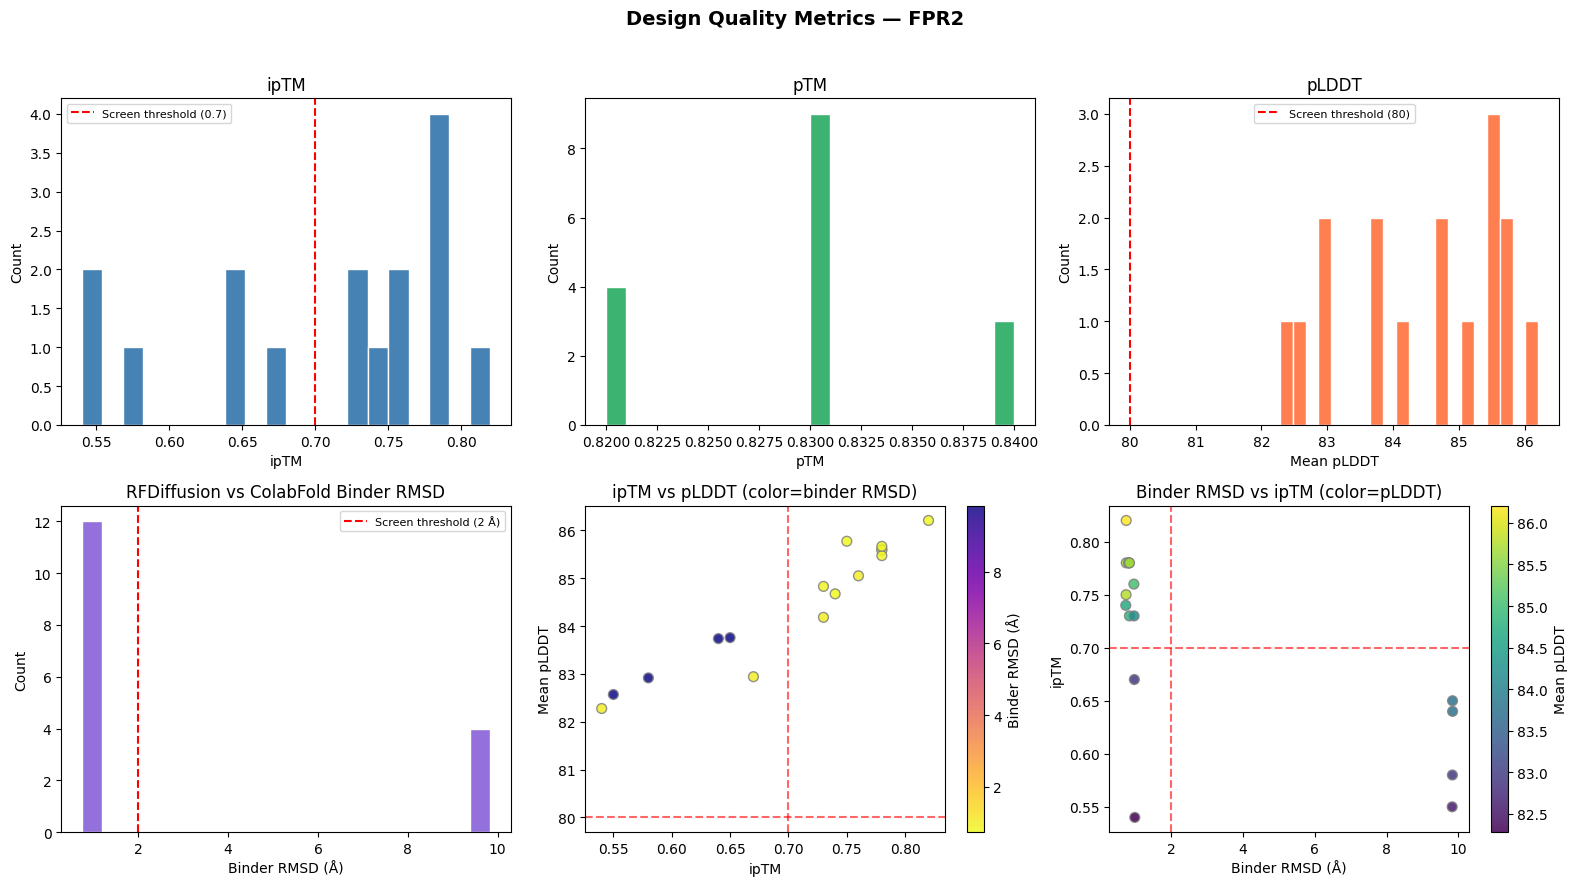


✅ Plot saved: /content/results_FPR2/FPR2_quality_metrics.png

Summary:


,binder_rmsd,ipTM,pTM,pLDDT,pAE_interface
count,16.000,16.000,16.000,16.000,16.000
mean,3.097,0.705,0.829,84.454,29.528
std,4.017,0.089,0.007,1.278,0.051
min,0.738,0.540,0.820,82.277,29.453
25%,0.806,0.648,0.827,83.539,29.469
50%,0.903,0.735,0.830,84.752,29.531
75%,3.199,0.780,0.830,85.590,29.578
max,9.836,0.820,0.840,86.209,29.594


In [13]:
#@title **5.1 — Quality Metrics Plots** { display-mode: "form" }
#@markdown > Histograms and scatter plots of all design metrics.

import matplotlib.pyplot as plt
import pandas as pd

ipTM_plot_threshold = globals().get("ipTM_threshold", 0.5)
pLDDT_plot_threshold = globals().get("pLDDT_threshold", 80)
RMSD_plot_threshold = globals().get("RMSD_threshold", 2.0)
metrics_plot_path = os.path.join(RESULTS_DIR, f"{TARGET_NAME}_quality_metrics.png")

if len(df_metrics) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"Design Quality Metrics — {TARGET_NAME}", fontsize=14, fontweight="bold")
    axes = axes.ravel()

    ax = axes[0]
    ax.hist(df_metrics["ipTM"].dropna(), bins=20, color="steelblue", edgecolor="white")
    ax.axvline(ipTM_plot_threshold, color="red", ls="--", label=f"Screen threshold ({ipTM_plot_threshold})")
    ax.set_xlabel("ipTM"); ax.set_ylabel("Count"); ax.set_title("ipTM"); ax.legend(fontsize=8)

    ax = axes[1]
    ax.hist(df_metrics["pTM"].dropna(), bins=20, color="mediumseagreen", edgecolor="white")
    ax.set_xlabel("pTM"); ax.set_ylabel("Count"); ax.set_title("pTM")

    ax = axes[2]
    ax.hist(df_metrics["pLDDT"].dropna(), bins=20, color="coral", edgecolor="white")
    ax.axvline(pLDDT_plot_threshold, color="red", ls="--", label=f"Screen threshold ({pLDDT_plot_threshold})")
    ax.set_xlabel("Mean pLDDT"); ax.set_ylabel("Count"); ax.set_title("pLDDT"); ax.legend(fontsize=8)

    ax = axes[3]
    rmsd_values = df_metrics["binder_rmsd"].dropna() if "binder_rmsd" in df_metrics else pd.Series(dtype=float)
    if len(rmsd_values) > 0:
        ax.hist(rmsd_values, bins=20, color="mediumpurple", edgecolor="white")
        ax.axvline(RMSD_plot_threshold, color="red", ls="--", label=f"Screen threshold ({RMSD_plot_threshold} Å)")
        ax.set_xlabel("Binder RMSD (Å)"); ax.set_ylabel("Count"); ax.set_title("RFDiffusion vs ColabFold Binder RMSD"); ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "No RMSD values available", ha="center", va="center")
        ax.set_axis_off()

    ax = axes[4]
    scatter_df = df_metrics.dropna(subset=["ipTM", "pLDDT", "binder_rmsd"])
    if len(scatter_df) > 0:
        sc = ax.scatter(
            scatter_df["ipTM"],
            scatter_df["pLDDT"],
            c=scatter_df["binder_rmsd"],
            cmap="plasma_r",
            s=50,
            edgecolor="gray",
            alpha=0.85,
        )
        ax.axvline(ipTM_plot_threshold, color="red", ls="--", alpha=0.6)
        ax.axhline(pLDDT_plot_threshold, color="red", ls="--", alpha=0.6)
        ax.set_xlabel("ipTM"); ax.set_ylabel("Mean pLDDT"); ax.set_title("ipTM vs pLDDT (color=binder RMSD)")
        plt.colorbar(sc, ax=ax, label="Binder RMSD (Å)")
    else:
        ax.text(0.5, 0.5, "No complete ipTM/pLDDT/RMSD rows", ha="center", va="center")
        ax.set_axis_off()

    ax = axes[5]
    scatter_df = df_metrics.dropna(subset=["binder_rmsd", "ipTM", "pLDDT"])
    if len(scatter_df) > 0:
        sc = ax.scatter(
            scatter_df["binder_rmsd"],
            scatter_df["ipTM"],
            c=scatter_df["pLDDT"],
            cmap="viridis",
            s=50,
            edgecolor="gray",
            alpha=0.85,
        )
        ax.axvline(RMSD_plot_threshold, color="red", ls="--", alpha=0.6)
        ax.axhline(ipTM_plot_threshold, color="red", ls="--", alpha=0.6)
        ax.set_xlabel("Binder RMSD (Å)"); ax.set_ylabel("ipTM"); ax.set_title("Binder RMSD vs ipTM (color=pLDDT)")
        plt.colorbar(sc, ax=ax, label="Mean pLDDT")
    else:
        ax.text(0.5, 0.5, "No complete RMSD/ipTM/pLDDT rows", ha="center", va="center")
        ax.set_axis_off()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(metrics_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\n✅ Plot saved: {metrics_plot_path}")
    print("\nSummary:")
    summary_cols = [c for c in ["binder_rmsd", "ipTM", "pTM", "pLDDT", "pAE_interface"] if c in df_metrics.columns]
    display(df_metrics[summary_cols].describe().round(3))
else:
    print("No data to plot")

---
## 6. 3D Visualization with py3Dmol

Interactive 3D visualization of your designed complexes:
- **Rotate**: Click and drag
- **Zoom**: Scroll wheel
- **Pan**: Right-click and drag

**Color scheme:**
- 🌈 **Rainbow**: Designed binder (chain A), colored N→C
- 🔵 **Light blue**: Target protein
- 🔴 **Red spheres**: Hotspot residues
- 🎨 **pLDDT coloring**: Blue=high confidence, Red=low confidence

In [14]:
#@title **6.1 — Visualize Target Protein** { display-mode: "form" }
#@markdown > Shows the target protein with hotspot residues highlighted as red spheres.

import py3Dmol

def show_pdb(pdb_file, width=800, height=500, style="cartoon"):
    with open(pdb_file) as f:
        pdb_data = f.read()
    view = py3Dmol.view(width=width, height=height)
    view.addModel(pdb_data, "pdb")
    view.setStyle({"chain": "A"}, {style: {"color": "spectrum"}})
    view.setStyle({"chain": TARGET_CHAIN}, {style: {"color": "lightblue"}})
    for hs in SELECT_HOTSPOTS:  # e.g. "A30"
        chain, resi = hs[0], int(hs[1:])
        view.addStyle({"chain": chain, "resi": resi},
                      {"sphere": {"radius": 0.8, "color": "red", "opacity": 0.6}})
    view.setBackgroundColor("white")
    view.zoomTo()
    return view

print(f"🎯 Target: {TARGET_NAME} — Hotspots: {SELECT_HOTSPOTS}")
view = show_pdb(pdb_path)
view.show()

🎯 Target: FPR2 — Hotspots: {'B84': 'CA', 'B88': 'CA', 'B172': 'CA', 'B180': 'CA', 'B263': 'CA', 'B266': 'CA', 'B176': 'CA', 'B173': 'CA', 'B262': 'CA'}


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 6.2  Best Design

The top-ranked design by ipTM score, showing the predicted binder-target complex.

In [15]:
#@title **6.2 — Visualize Best Design** { display-mode: "form" }
#@markdown > Shows the highest-scoring binder-target complex.

if len(cf_pdbs) > 0 and len(df_metrics) > 0:
    best = df_metrics.sort_values("ipTM", ascending=False).iloc[0]
    best_id = best["design_id"]
    best_pdb = next((p for p in cf_pdbs if best_id in p), cf_pdbs[0])

    print(f"🏆 Best: {best_id}")
    print(f"   ipTM={best['ipTM']:.3f}  pTM={best['pTM']:.3f}  pLDDT={best['pLDDT']:.1f}  length={best['length']}")

    view = show_pdb(best_pdb)
    view.show()
else:
    print("⚠️  No predictions to visualize")

🏆 Best: inputs_fpr2_binder_0_model_1.cif_b3_d0
   ipTM=0.820  pTM=0.840  pLDDT=86.2  length=18


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 6.3  Compare Multiple Designs

Side-by-side visualization of top designs. Adjust how many to display.

In [20]:
#@title **6.3 — Compare Best Designs (Grid)** { display-mode: "form" }

#@markdown ### How many best designs to show?
n_show = 4  #@param {type:"slider", min:1, max:12, step:1}

if len(cf_pdbs) > 0 and len(df_metrics) > 0:
    # Select only designs that passed the screening filter, ranked by ipTM
    best_df = (
        df_metrics[df_metrics["pass_filter"] == True]
        .sort_values("ipTM", ascending=False)
        .head(n_show)
    )
    if len(best_df) == 0:
        print("⚠️  No designs passed the filter. Showing top designs by ipTM instead.")
        best_df = df_metrics.sort_values("ipTM", ascending=False).head(n_show)

    print(f"Showing {len(best_df)} best designs (pass_filter=True, sorted by ipTM):\n")

    for rank, (_, r) in enumerate(best_df.iterrows(), 1):
        design_id = r["design_id"]
        pdb_match = [p for p in cf_pdbs if design_id in Path(p).name]
        if not pdb_match:
            print(f"  Design {rank}: {design_id} — PDB not found, skipping")
            continue
        pdb_file = pdb_match[0]

        rmsd_str = f" RMSD={r['binder_rmsd']:.2f}A" if pd.notna(r.get('binder_rmsd')) else ""
        tag = f"ipTM={r['ipTM']:.3f} pLDDT={r['pLDDT']:.0f}{rmsd_str}"
        print(f"  Design {rank}: {design_id[:45]} ({tag})")

        with open(pdb_file) as f:
            data = f.read()
        v = py3Dmol.view(width=400, height=300)
        v.addModel(data, "pdb")
        v.setStyle({"chain": "A"}, {"cartoon": {"color": "spectrum"}})
        v.setStyle({"chain": TARGET_CHAIN}, {"cartoon": {"color": "lightblue"}})
        v.setBackgroundColor("white"); v.zoomTo(); v.show()
else:
    print("No predictions to display")

Showing 4 best designs (pass_filter=True, sorted by ipTM):

  Design 1: inputs_fpr2_binder_0_model_1.cif_b3_d0 (ipTM=0.820 pLDDT=86 RMSD=0.75A)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  Design 2: inputs_fpr2_binder_0_model_1.cif_b0_d0 (ipTM=0.780 pLDDT=86 RMSD=0.75A)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  Design 3: inputs_fpr2_binder_0_model_2.cif_b3_d0 (ipTM=0.780 pLDDT=86 RMSD=0.84A)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

  Design 4: inputs_fpr2_binder_0_model_2.cif_b0_d0 (ipTM=0.780 pLDDT=86 RMSD=0.82A)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 6.4  pLDDT Confidence Coloring

Residues colored by AlphaFold2 confidence:
- 🔵 **Blue** (>90): Very high — reliable
- 🔷 **Cyan** (70-90): High — mostly reliable
- 🟡 **Yellow** (50-70): Low — uncertain
- 🟠 **Orange** (<50): Very low — likely disordered

In [21]:
#@title **6.4 — pLDDT Confidence Coloring** { display-mode: "form" }
#@markdown > Colors each residue by predicted confidence (stored in B-factor).

if len(cf_pdbs) > 0:
    best_pdb_path = cf_pdbs[0]
    if len(df_metrics) > 0:
        bid = df_metrics.sort_values("ipTM", ascending=False).iloc[0]["design_id"]
        best_pdb_path = next((p for p in cf_pdbs if bid in p), cf_pdbs[0])

    with open(best_pdb_path) as f:
        data = f.read()

    view = py3Dmol.view(width=800, height=500)
    view.addModel(data, "pdb")
    view.setStyle({}, {"cartoon": {"colorscheme": {
        "prop": "b", "gradient": "roygb", "min": 0, "max": 100
    }}})
    view.setBackgroundColor("white"); view.zoomTo()

    print(f"🎨 pLDDT coloring — {Path(best_pdb_path).stem}")
    view.show()
else:
    print("No predictions available")

🎨 pLDDT coloring — inputs_fpr2_binder_0_model_1.cif_b3_d0_relaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---
## 7. Download Results

Package all generated files into a ZIP for download:
backbones, sequences, predictions, the metrics CSV, and saved plot images.

In [19]:
#@title **7.0 — Package & Download Results** { display-mode: "form" }
#@markdown > Creates a ZIP file with all outputs and triggers download.

import zipfile

zip_path = f"/content/{TARGET_NAME}_designs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    csv_p = os.path.join(RESULTS_DIR, "design_metrics.csv")
    if os.path.isfile(csv_p):
        zf.write(csv_p, "design_metrics.csv")

    for plot_path in sorted(glob.glob(os.path.join(RESULTS_DIR, "*.png"))):
        zf.write(plot_path, f"04_plots/{os.path.basename(plot_path)}")

    for f in rfd3_outputs:
        zf.write(f, f"01_backbones/{os.path.basename(f)}")
    for f in mpnn_fastas:
        zf.write(f, f"02_sequences/{os.path.basename(f)}")
    for f in cf_pdbs:
        zf.write(f, f"03_predictions/{os.path.basename(f)}")

print(f"📦 {zip_path} ({os.path.getsize(zip_path)/1024:.1f} KB)")

from google.colab import files
files.download(zip_path)
print("✅ Download started!")

📦 /content/FPR2_designs.zip (2607.0 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


---
## 📊 Pipeline Summary

| Stage | Tool | Output |
|-------|------|--------|
| 1 | **RFdiffusion3** | Backbone structures (`.cif.gz`) |
| 2 | **LigandMPNN / solMPNN** | Amino acid sequences (`.fasta`) |
| 3 | **ColabFold** | Predicted structures (`.pdb`) + quality scores |
| 4 | **Screening** | Filtered metrics (`design_metrics.csv`) + quality plots (`.png`) |

**Next steps:**
1. Scale up (more backbones, more sequences per backbone)
2. Prioritize low-RMSD, high-ipTM candidates
3. Run molecular dynamics on top candidates
4. Order gene synthesis for experimental validation

**References:**
- Watson et al. (2023) *De novo design with RFdiffusion*. Nature.
- Dauparas et al. (2022) *ProteinMPNN*. Science.
- Mirdita et al. (2022) *ColabFold*. Nature Methods.
- Krishna et al. (2024) *RFdiffusion3*. bioRxiv.